
# Kernel and non-Kernel Classifiers Comparison

**Learning Outcomes**
1. Compare kernel classifiers with other types of classifiers such neural net and kNN on a classification problem to appreciate their strengths and weaknesses
2. Develop mindfulness about the difference when it comes to high dimensional dataset


In this exercise you make a comparison of a several classifiers in scikit-learn on synthetic datasets.
The point of this example is to illustrate the nature of decision boundaries
of different classifiers.
This should be taken with a grain of salt, as the intuition conveyed by these examples does not necessarily carry over to real datasets.


The plots show training points in solid colours and testing points semi-transparent. The lower right shows the classification accuracy on the test set.


In [1]:
%matplotlib inline

In [48]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# Modified slightly by Abdulrahman Altahhan
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

h = .02  # step size in the mesh


In [57]:
names = ["Nearest Neighbors", "Decision Tree", "Random Forest (max depth: 5)", "Neural Net", "SVM w/ RBF kernel", "Gaussian Process w/ RBF kernel"]
C = 1.0  # SVM regularization parameter
kernel = 1.0 * RBF([1.0]) # GP kernel parameter
classifiers = [
    KNeighborsClassifier(3),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    svm.SVC(kernel='rbf', gamma=0.7, C=C),
    GaussianProcessClassifier(kernel=kernel)]

X, y = make_classification(n_features=4, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)  # make X elements 2 times larger?
linearly_separable = (X, y)

# Making 3 datasets: moons, circles, linearly_separable
datasets = [make_moons(noise=0.3, random_state=0),
            make_circles(noise=0.2, factor=0.5, random_state=1),
            linearly_separable ]



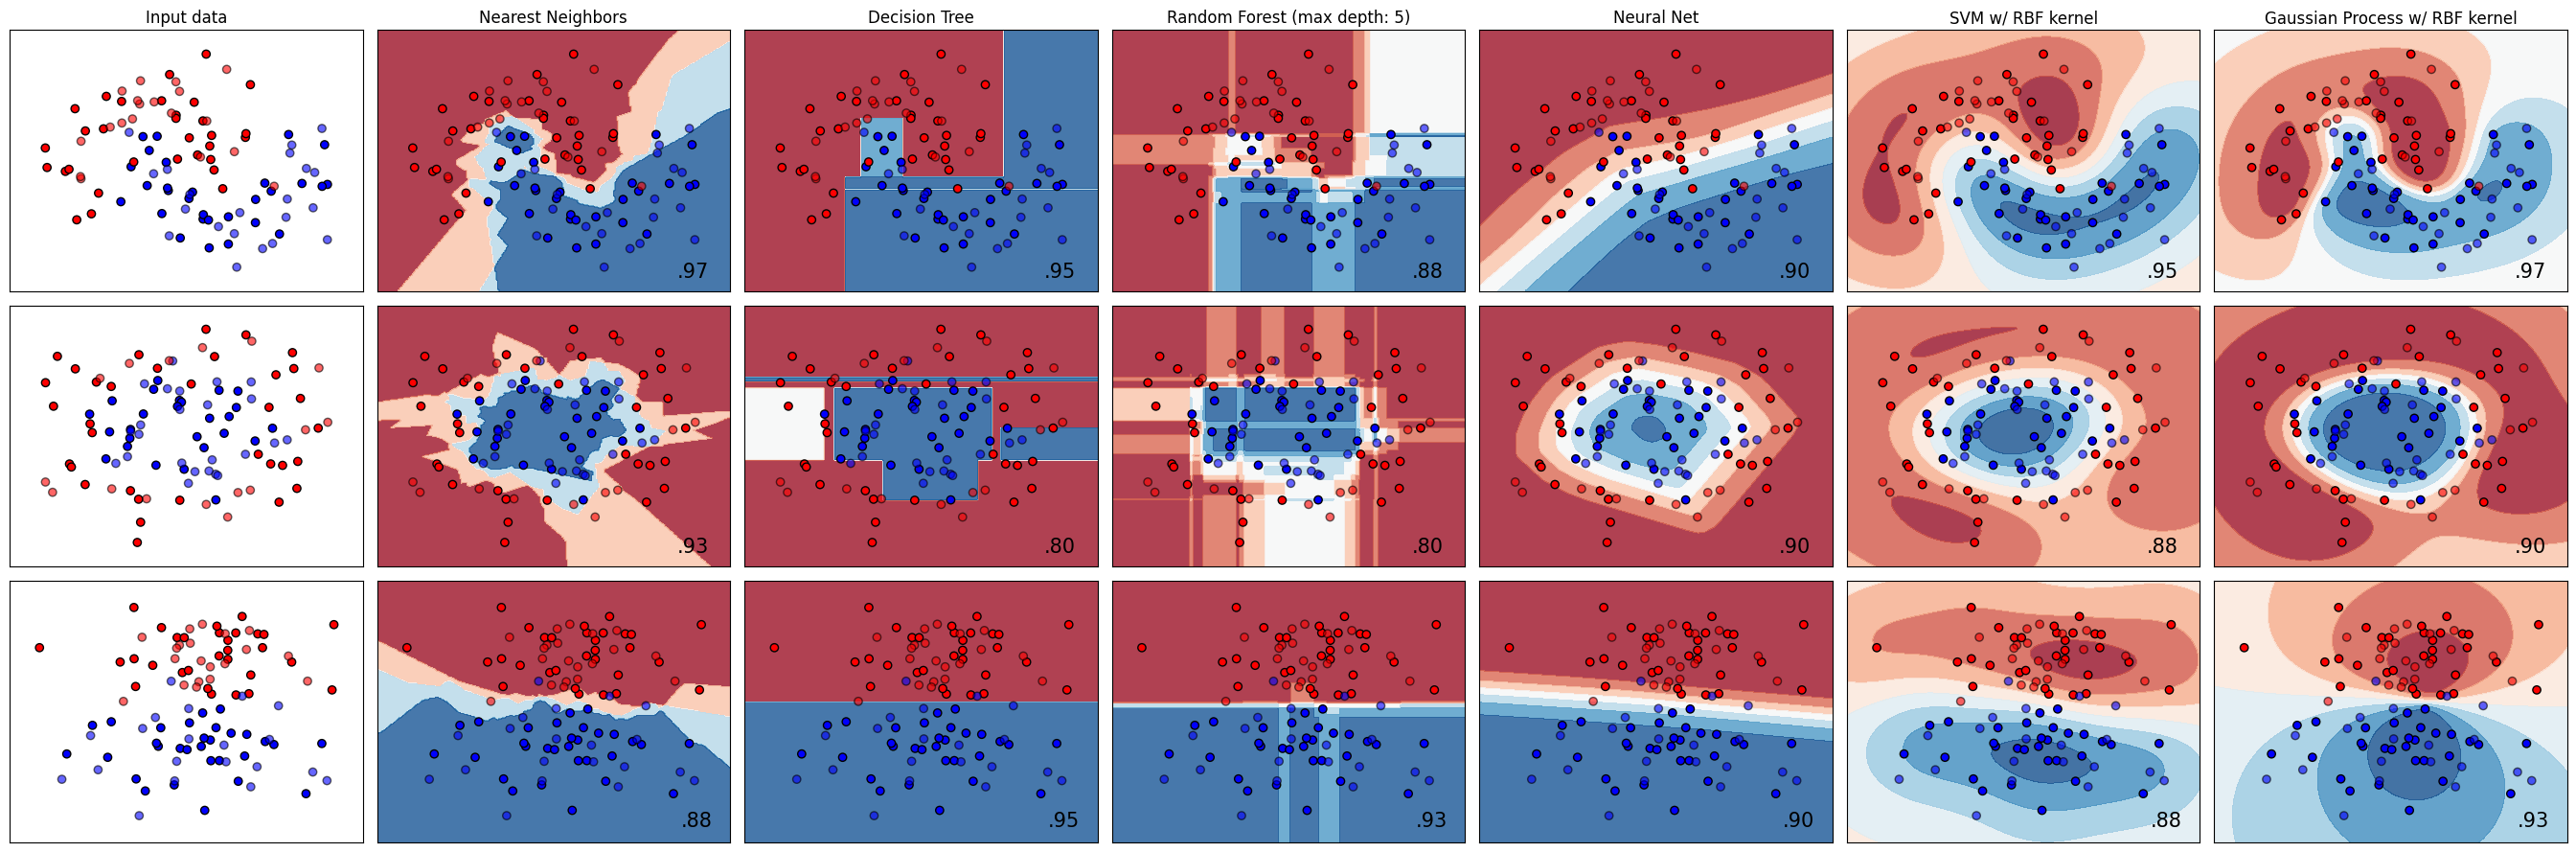

In [60]:
figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.4, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:       ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,  edgecolors='k')
    
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # For 2D plotting:
        clf.fit(X_train[:,:2], y_train)
        
        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        if hasattr(clf, "decision_function"):          Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:                                          Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Put the result into a colour plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)
        
        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,  edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:     ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'), size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

Note how kernel method (SVM and GP) boundaries seems the richest and has a more circular or moon shaped boundaries. They coinside more with our conceptions of the boundaries than other methods. Kernel methods, Neural Nets and kNN can come up with arbitrary decision boundary depending on the dataset, while DT Random Forest has as usual a rectilinear shape.

## Your turn


1. change the kernels and see the effect on the decision boundaries



In [68]:
names = ['SVM w/ C = 0.5', 'SVM w/ C = 1.0', 'SVM w/ C = 1.5',
         'GPC w/ 1xRBF([0.5])','GPC w/ 1xRBF([1.0])', 'GPC w/ 1xRBF([1.5])',
         'GPC w/ 0.5xRBF([1.0])','GPC w/ 1xRBF([1.0])', 'GPC w/ 1.5xRBF([1.0])']
#kernel = 1.0 * RBF([1.0]) # GP kernel parameter
classifiers = [
    svm.SVC(kernel='rbf', gamma=0.7, C=0.5),
    svm.SVC(kernel='rbf', gamma=0.7, C=1.0),
    svm.SVC(kernel='rbf', gamma=0.7, C=1.5),
    GaussianProcessClassifier(kernel=1.0 * RBF([0.5])),
    GaussianProcessClassifier(kernel=1.0 * RBF([1.0])),
    GaussianProcessClassifier(kernel=1.0 * RBF([1.5])),
    GaussianProcessClassifier(kernel=0.5 * RBF([1.0])),
    GaussianProcessClassifier(kernel=1.0 * RBF([1.0])),
    GaussianProcessClassifier(kernel=1.5 * RBF([1.0]))]

2. Tackle higher dimensional dataset by changing n_features and compare the performance of the classifiers using our usual metrics such as the F1 measure and the balanced accuracy etc.

[ 2  4  6  8 10 12 14 16 18 20]


C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


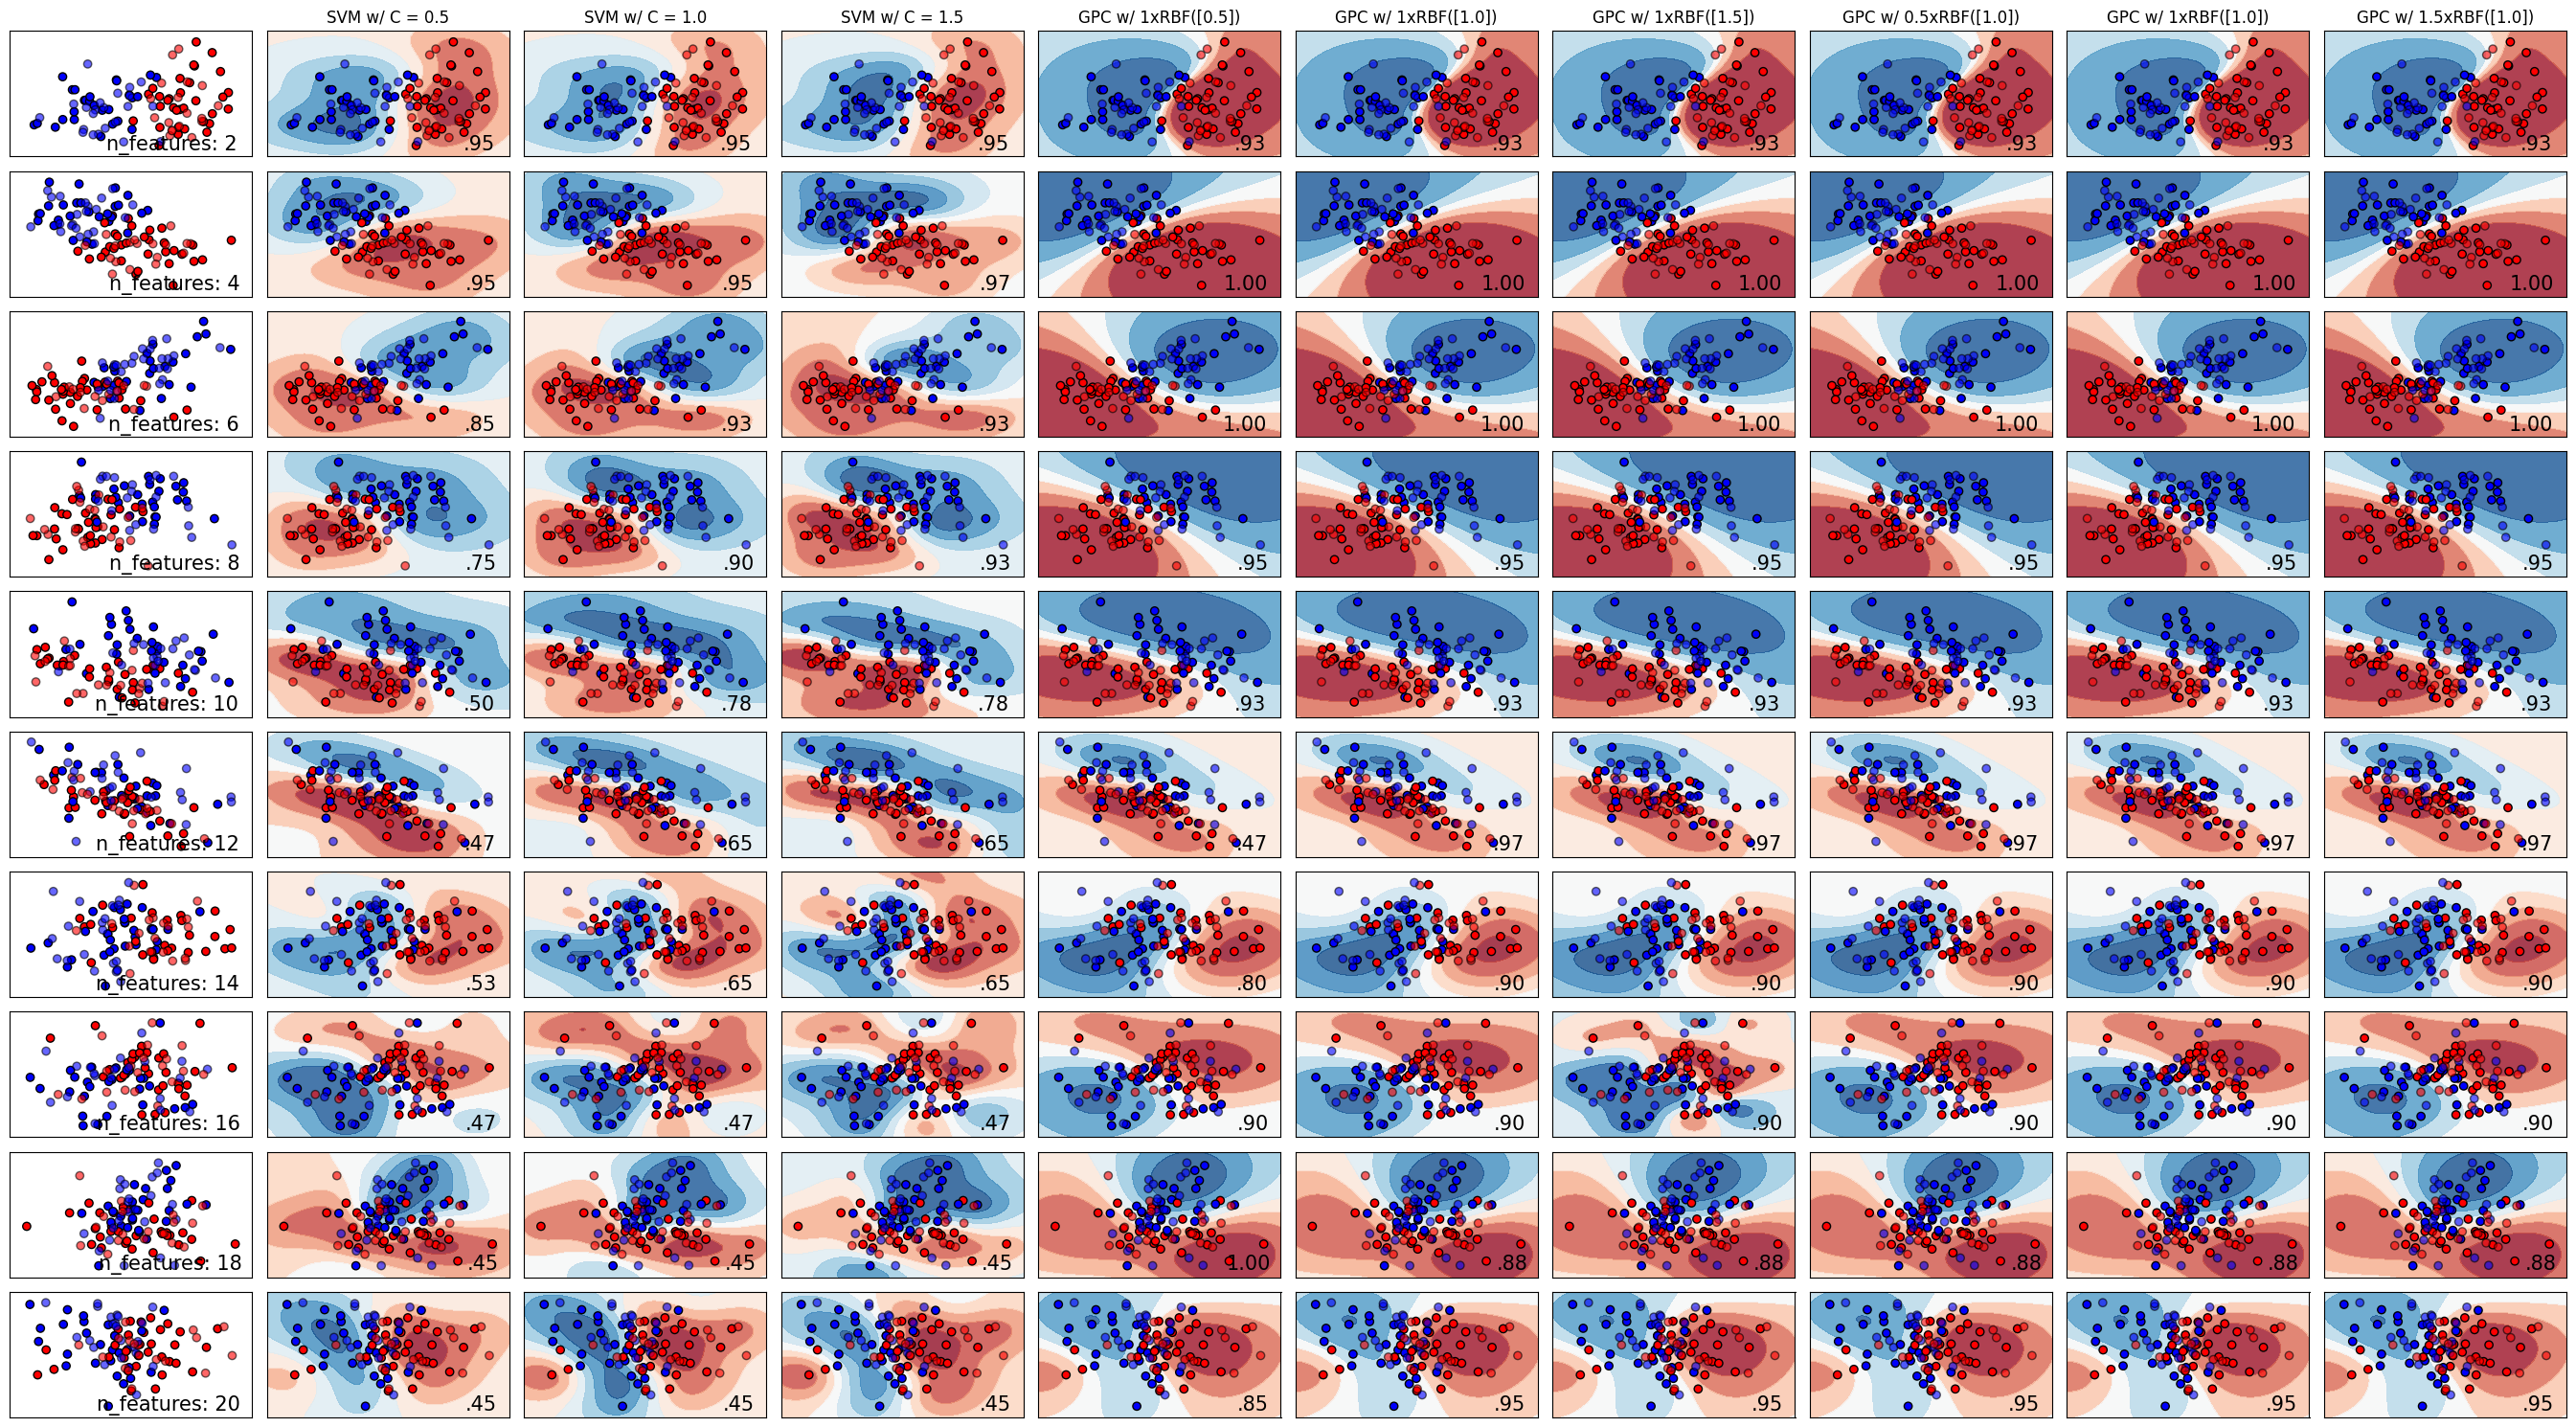

In [69]:
figure = plt.figure(figsize=(27, 15))

n_features = np.arange(2, 22, 2)
print(n_features)
i = 1
for num, n in enumerate(n_features):
    X, y = make_classification(n_features=n, n_redundant=0, n_informative=n,
                           random_state=1, n_clusters_per_class=1)
    rng = np.random.RandomState(2)
    X += 2 * rng.uniform(size=X.shape)  # make X elements 2 times larger?

    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(n_features), len(classifiers) + 1, i)
    if ds_cnt == 0:       ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,  edgecolors='k')
    
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.text(xx.max() - .3, yy.min() + .3, f'n_features: {n}', size=15, horizontalalignment='right')
    i += 1

    for name, clf in zip(names, classifiers):
        #print(f'num: {num}; working on {name}')
        ax = plt.subplot(len(n_features), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # For 2D plotting of contours:
        clf.fit(X_train[:,:2], y_train)
        
        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        if hasattr(clf, "decision_function"):          Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:                                          Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Put the result into a colour plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,  edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if num == 0:     ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'), size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()